In [1]:
import numpy as np
import networkx as nx
import scipy.sparse as scipy_sparse

from qlinks.caging import (
    CageSearchConfig,
    CageSearcher,
)
from qlinks.models import (
    SquareQLMModel,
    SquareQDMModel,
    TriangularQLMModel,
    TriangularQDMModel,
    HoneycombQLMModel,
    HoneycombQDMModel,
)
from qlinks.visualizer import (
    BasisGridVisualizer,
    HamiltonianGraphStyle,
    HamiltonianGraphVisualizer,
)

In [2]:
def diagonal_values(matrix) -> np.ndarray:
    """Return diagonal values of a dense or sparse matrix."""
    if scipy_sparse.issparse(matrix):
        values = matrix.diagonal()
    else:
        values = np.diag(matrix)

    return np.asarray(values, dtype=np.complex128)


def offdiagonal_nnz(matrix) -> int:
    """Return number of off-diagonal nonzero entries."""
    sparse_matrix = scipy_sparse.csr_array(matrix).copy()
    sparse_matrix.setdiag(0)
    sparse_matrix.eliminate_zeros()

    return int(sparse_matrix.nnz)


def finite_amplitude_indices(
    state_vector: np.ndarray,
    *,
    tolerance: float = 1e-12,
) -> np.ndarray:
    """Return basis indices with numerically nonzero amplitude."""
    return np.flatnonzero(np.abs(state_vector) > tolerance).astype(np.int64)


def basis_states_array(basis):
    """Extract the raw basis-state array."""
    if hasattr(basis, "states"):
        return np.asarray(basis.states)

    if hasattr(basis, "configs"):
        return np.asarray(basis.configs)

    raise AttributeError(
        "Expected basis to expose either `states` or `configs`."
    )

In [3]:
model = TriangularQDMModel(
    lx=4,
    ly=4,
    boundary_condition="periodic",
    winding_a=0,
    winding_b=0,
    kinetic=1.0,
    potential=1.0,
)

build_result = model.build(
    basis_solver="dfs",
    builder="sparse",
    backend="scipy",
    sort_basis=True,
    on_missing="raise",
)

hamiltonian_matrix = build_result.hamiltonian
kinetic_matrix = build_result.kinetic
potential_matrix = build_result.potential
basis = build_result.basis

print("n_states =", basis.n_states)
print("H shape =", hamiltonian_matrix.shape)
print("H nnz =", hamiltonian_matrix.nnz)
print("K nnz =", kinetic_matrix.nnz)
print("K offdiag nnz =", offdiagonal_nnz(kinetic_matrix))
print("V nnz =", potential_matrix.nnz)
print("K is bipartite =", nx.is_bipartite(nx.from_scipy_sparse_array(kinetic_matrix, edge_attribute="weight")))

n_states = 576
H shape = (576, 576)
H nnz = 3456
K nnz = 2880
K offdiag nnz = 2880
V nnz = 576
K is bipartite = True


In [ ]:
searcher = CageSearcher.from_model_build_result(
    build_result,
    config=CageSearchConfig(
        search_type="qdm",
        # type1_kappas=(0,),
        # type2_kappas=(-2, 2),
        tolerance=1e-10,
    ),
)

result = searcher.run()
print(result.counts_by_signature)

In [4]:
record = result.first(signature=(0, 4))
full_state = record.full_state

{(0, 4): 12, (0, 6): 9}


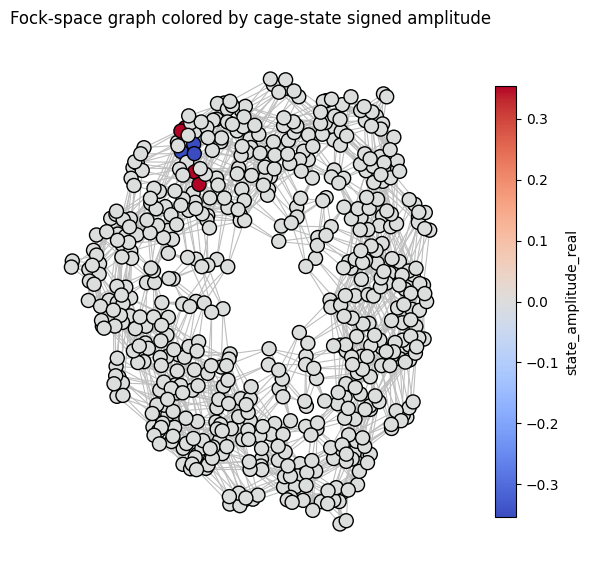

<Axes: title={'center': 'Fock-space graph colored by cage-state signed amplitude'}>

In [5]:
graph_visualizer = HamiltonianGraphVisualizer.from_sparse_matrix(
    kinetic_matrix,
    include_self_loops=False,
    style=HamiltonianGraphStyle(cmap="coolwarm"),
)

graph_visualizer.plot(
    backend="igraph",
    color_by="state_amplitude_real",
    state_vector=full_state,
    layout="kk",
    title=f"Fock-space graph colored by cage-state signed amplitude",
)

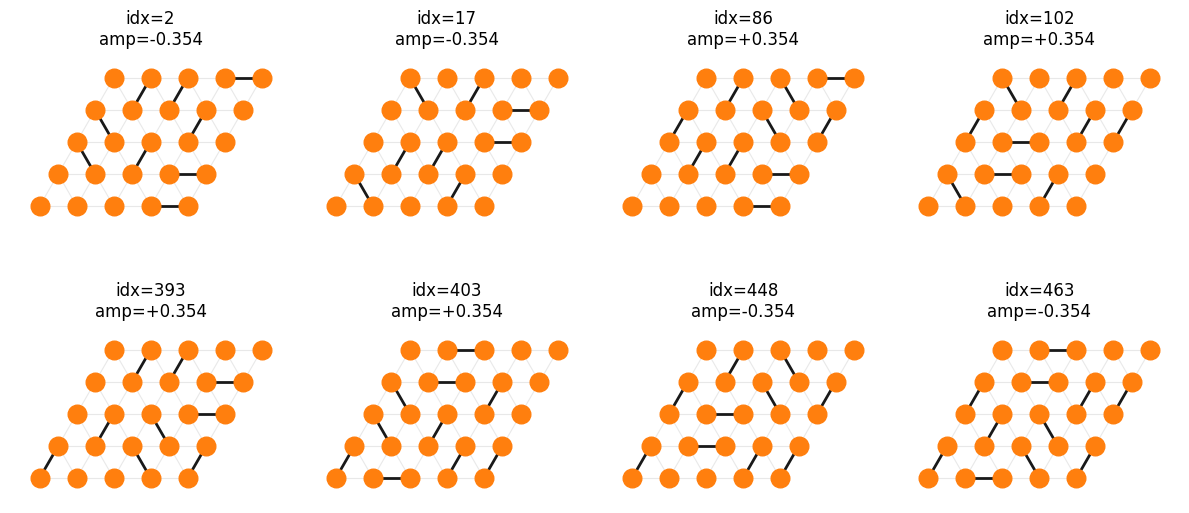

(<Figure size 1200x600 with 8 Axes>,
 array([[<Axes: title={'center': 'idx=2\namp=-0.354'}>,
         <Axes: title={'center': 'idx=17\namp=-0.354'}>,
         <Axes: title={'center': 'idx=86\namp=+0.354'}>,
         <Axes: title={'center': 'idx=102\namp=+0.354'}>],
        [<Axes: title={'center': 'idx=393\namp=+0.354'}>,
         <Axes: title={'center': 'idx=403\namp=+0.354'}>,
         <Axes: title={'center': 'idx=448\namp=-0.354'}>,
         <Axes: title={'center': 'idx=463\namp=-0.354'}>]], dtype=object))

In [7]:
grid_visualizer = BasisGridVisualizer(
    lattice=model.lattice,
    layout=model.layout,
    periodic_image_mode="positive_patch",
    collapse_duplicate_visual_links=True,
    site_label_style="sublattice_cell",
    # coordinate_transform=np.array(
    #     [
    #         [1.0, 0.0],
    #         [0.0, 0.72],
    #     ],
    #     dtype=float,
    # ),
    # style=LinkVisualStyle(
    #     node_size=50.0,
    #     # plaquette_symbol_offset=(-0.01, 0.01),
    # ),
)

support_states = build_result.basis.states[record.support]

grid_visualizer.plot(
    support_states,
    labels=[
        f"idx={int(index)}\namp={full_state[int(index)].real:+.3g}"
        for index in record.support
    ],
    ncols=4,
    mode="dimers",
    plaquette_symbols="none",
    show_config_label=False,
    # suptitle="Basis states with finite cage-state amplitude",
    single_plot_kwargs={
        "with_site_labels": False,
        "with_site_values": False,
        "with_link_values": False,
    },
)

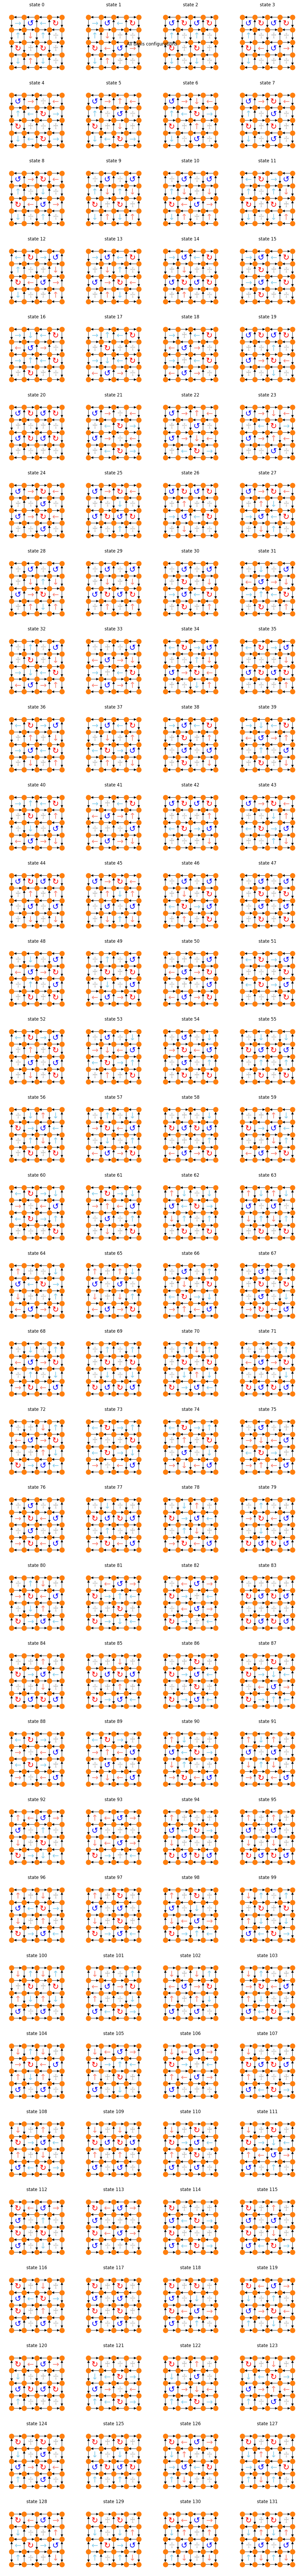

(<Figure size 1200x9900 with 132 Axes>,
 array([[<Axes: title={'center': 'state 0'}>,
         <Axes: title={'center': 'state 1'}>,
         <Axes: title={'center': 'state 2'}>,
         <Axes: title={'center': 'state 3'}>],
        [<Axes: title={'center': 'state 4'}>,
         <Axes: title={'center': 'state 5'}>,
         <Axes: title={'center': 'state 6'}>,
         <Axes: title={'center': 'state 7'}>],
        [<Axes: title={'center': 'state 8'}>,
         <Axes: title={'center': 'state 9'}>,
         <Axes: title={'center': 'state 10'}>,
         <Axes: title={'center': 'state 11'}>],
        [<Axes: title={'center': 'state 12'}>,
         <Axes: title={'center': 'state 13'}>,
         <Axes: title={'center': 'state 14'}>,
         <Axes: title={'center': 'state 15'}>],
        [<Axes: title={'center': 'state 16'}>,
         <Axes: title={'center': 'state 17'}>,
         <Axes: title={'center': 'state 18'}>,
         <Axes: title={'center': 'state 19'}>],
        [<Axes: title={'c

In [4]:
grid_visualizer = BasisGridVisualizer(
    lattice=model.lattice,
    layout=model.layout,
    periodic_image_mode="positive_patch",
    collapse_duplicate_visual_links=True,
    # site_label_style="sublattice_cell",
    # coordinate_transform=np.array(
    #     [
    #         [1.0, 0.0],
    #         [0.0, 0.72],
    #     ],
    #     dtype=float,
    # ),
    # style=LinkVisualStyle(
    #     node_size=50.0,
    #     # plaquette_symbol_offset=(-0.01, 0.01),
    # ),
)

grid_visualizer.plot(
    basis.states,
    ncols=4,
    mode="arrows",
    plaquette_symbols="square_qlm",
    show_config_label=False,
    suptitle="All basis configurations",
    single_plot_kwargs={
        "with_site_labels": False,
        "with_site_values": False,
        "with_link_values": False,
    },
)